In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("spam_Emails_data.csv")

df.head()

,label,text
0,Spam,viiiiiiagraaaa\nonly for the ones that want to...
1,Ham,got ice thought look az original message ice o...
2,Spam,yo ur wom an ne eds an escapenumber in ch ma n...
3,Spam,start increasing your odds of success & live s...
4,Ham,author jra date escapenumber escapenumber esca...


In [3]:
df.shape

(193852, 2)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 193852 entries, 0 to 193851
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   label   193852 non-null  str  
 1   text    193850 non-null  str  
dtypes: str(2)
memory usage: 3.0 MB


In [5]:
df.isnull().sum()

label    0
text     2
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['label'].value_counts()

label
Ham     102160
Spam     91692
Name: count, dtype: int64

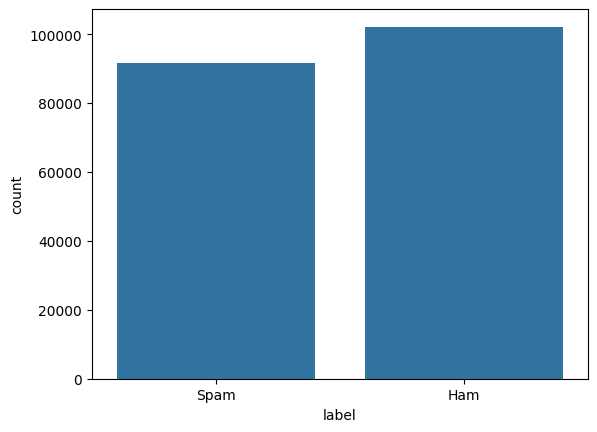

In [8]:
sns.countplot(x='label', data=df)
plt.show()

In [9]:
df.isnull().sum()

label    0
text     2
dtype: int64

In [10]:
df = df.dropna(subset=['text'])

In [11]:
df['char_count'] = df['text'].apply(len)

In [12]:
df['word_count'] = df['text'].apply(
    lambda x: len(x.split())
)

In [13]:
df['avg_word_len'] = (
    df['char_count'] /
    df['word_count']
)

In [14]:
df[['char_count','word_count']].describe()

,char_count,word_count
count,1.938500e+05,1.938500e+05
mean,1.812779e+03,2.760373e+02
std,2.659510e+04,3.671773e+03
min,1.000000e+00,1.000000e+00
25%,3.620000e+02,5.500000e+01
50%,8.000000e+02,1.270000e+02
75%,1.803000e+03,2.800000e+02
max,1.151031e+07,1.585483e+06


In [15]:
df.groupby('label')[
    ['char_count','word_count']
].mean()

,char_count,word_count
label,,
Ham,2169.722912,334.573498
Spam,1415.085112,210.818314


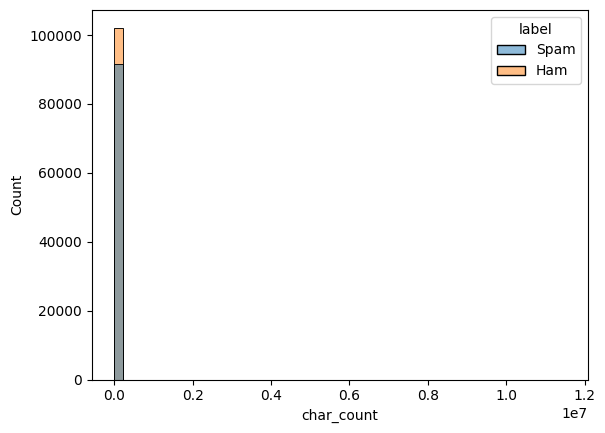

In [16]:
sns.histplot(
    data=df,
    x='char_count',
    hue='label',
    bins=50
)

plt.show()

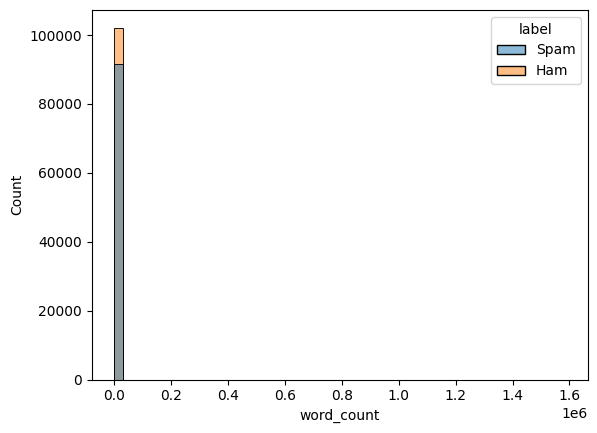

In [17]:
sns.histplot(
    data=df,
    x='word_count',
    hue='label',
    bins=50
)

plt.show()

In [18]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/mynk/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/mynk/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

In [20]:
import nltk

df['sentence_count'] = df['text'].apply(
    lambda x: len(nltk.sent_tokenize(x))
)

In [21]:
df['char_count'] = df['text'].apply(len)

df['word_count'] = df['text'].apply(
    lambda x: len(x.split())
)

In [22]:
df['label'].value_counts()

label
Ham     102159
Spam     91691
Name: count, dtype: int64

In [23]:
ps = PorterStemmer()

stop_words = set(
    stopwords.words('english')
)

In [24]:
def transform_text(text):

    text = text.lower()

    words = word_tokenize(text)

    cleaned = []

    for word in words:

        if word.isalnum():

            if word not in stop_words:

                cleaned.append(
                    ps.stem(word)
                )

    return " ".join(cleaned)

In [25]:
df['transformed_text'] = df['text'].apply(
    transform_text
)

In [26]:
df[['text','transformed_text']].head()

,text,transformed_text
0,viiiiiiagraaaa\nonly for the ones that want to...,viiiiiiagraaaa one want make scream prodigi sc...
1,got ice thought look az original message ice o...,got ice thought look az origin messag ice oper...
2,yo ur wom an ne eds an escapenumber in ch ma n...,yo ur wom ne ed escapenumb ch n b e th n f h e...
3,start increasing your odds of success & live s...,start increas odd success live sexual healthi ...
4,author jra date escapenumber escapenumber esca...,author jra date escapenumb escapenumb escapenu...


In [27]:
df['label'] = df['label'].map({
    'Ham':0,
    'Spam':1
})

In [28]:
df['label'].value_counts()

label
0    102159
1     91691
Name: count, dtype: int64

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

In [30]:
X = tfidf.fit_transform(
    df['transformed_text']
).toarray()

y = df['label']

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

I0000 00:00:1781652307.748558   73026 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781652307.765078   73026 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781652310.694408   73026 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781652314.028697   73026 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [33]:
model = Sequential([
    
    Dense(
        128,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    Dense(
        64,
        activation='relu'
    ),

    Dense(
        32,
        activation='relu'
    ),

    Dense(
        1,
        activation='sigmoid'
    )
])

/home/mynk/miniconda3/envs/ml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1781652314.558878   73026 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1781652314.559378   74889 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1781652314.580679   73026 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to

In [34]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [35]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,497 (2.48 MB)

 Trainable params: 650,497 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
970/970 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9633 - loss: 0.0994 - val_accuracy: 0.9782 - val_loss: 0.0643
Epoch 2/10
970/970 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9867 - loss: 0.0397 - val_accuracy: 0.9836 - val_loss: 0.0516
Epoch 3/10
970/970 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9948 - loss: 0.0174 - val_accuracy: 0.9845 - val_loss: 0.0571
Epoch 4/10
970/970 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9975 - loss: 0.0087 - val_accuracy: 0.9858 - val_loss: 0.0637
Epoch 5/10
970/970 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9983 - loss: 0.0059 - val_accuracy: 0.9848 - val_loss: 0.0813
Epoch 6/10
970/970 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9986 - loss: 0.0048 - val_accuracy: 0.9858 - val_loss: 0.0867
Epoch 7/10
970/970 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9985 - loss: 0.0048 - val_accuracy: 0.9844 - val_loss: 0.0975
Epoch 8/10
970/970 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9985 - loss: 0.0051 - val_accuracy: 0.

In [37]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:", accuracy)

1212/1212 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9861 - loss: 0.1039
Accuracy: 0.9860717058181763


In [38]:
pred = model.predict(X_test)

pred = (pred > 0.5).astype(int)

1212/1212 ━━━━━━━━━━━━━━━━━━━━ 1s 849us/step


In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [40]:
print("Accuracy:",
      accuracy_score(y_test,pred))

print("Precision:",
      precision_score(y_test,pred))

print("Recall:",
      recall_score(y_test,pred))

print("F1 Score:",
      f1_score(y_test,pred))

Accuracy: 0.9860717049264895
Precision: 0.981247649239697
Recall: 0.9896493795046876
F1 Score: 0.9854306065184546
